# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

### Background: From one flat reason code to a real taxonomy

In ML-07, my baseline rule flagged every underperforming page with a single reason code: `SEVERE_CTR_GAP`. But my top-20 manual review exposed three distinct failure patterns hiding inside that one flat label:

1. **Zero-click SERPs** — huge impressions, literally zero clicks. The page might be unclickable, not broken.
2. **Branded / competitor search** — the page ranks high but users skip it because they were searching for a specific competitor.
3. **Legitimately broken title** — getting some clicks, just fewer than it should. A real fix candidate.

The baseline rule can't tell these apart — every row says the same thing. That's the exact gap this playbook fills: splitting one blunt flag into distinct archetypes, each with its own rule, action, and team.

A fourth pattern emerged during analysis: pages where the **snippet works fine** (good CTR) **but the content fails** (users click and immediately bounce). This is the opposite problem — fixing the title would actually break a working snippet. It needs a completely different action (audit content/UX, not rewrite metadata).

### Constraint: Only features I already have

I distinguish these archetypes using **only** the features already in my ML-07 dataframe — no new data pulled:
- `total_clicks`, `total_impressions`, `ctr` (derived)
- `average_position`, `position_tier` (derived)
- `total_engaged_sessions`, `engagement_rate` (derived: engaged_sessions / clicks)

### Thresholds: Derived from data, not invented

Every numeric cutoff below traces back to my own ML-04/ML-07 analysis:

| Source | Values |
|---|---|
| **CTR by position tier** (ML-07, n=42,174) | top_3: 0.39%, page_1: 0.35%, striking: 0.29%, page_3_5: 0.15%, deep: 0.03% |
| **Impression tiers** (ML-04) | moderate ≥ 300, good ≥ 3,000, excellent ≥ 30,000 |
| **Click distribution** (ML-07, 75th pctl = 10) | 50% of eligible pages get ≤ 3 clicks; 75% get ≤ 10 clicks |
| **Engagement rate distribution** (ML-07) | median = 0.0; 75th pctl = 0.056; 90th pctl = 0.20 |

---

### The Evaluation Funnel (Precedence Order)

Every page is evaluated **top-down** through this list. A page can only belong to **one** archetype — the first one that fires claims it.

**Why this order?**

1. **Filter out broken/unactionable noise first** (Archetypes 1 & 2). If I don't, I waste writer-hours on zero-click SERPs and competitor branded terms.
2. **Separate content failures from metadata failures** (Archetype 3 before 4). If a page fails both CTR and engagement, the content is the deeper root cause — fixing content might also fix CTR, but fixing the title alone can't fix broken content.
3. **Only then flag true metadata candidates** (Archetype 4). By this point, anything landing here is guaranteed to have a working page behind a bad snippet.
4. **Catch-all for thin evidence** (Archetype 5). Refuse to act on statistical noise.

I derived this order from **cost-of-error reasoning**: at each step, I default to the archetype whose mistake is cheaper and more recoverable. Skipping a page costs nothing; sending a writer to fix a title on a page with broken content wastes real hours and doesn't solve the problem.

---

### Archetype 1: Zero-Click Anomaly
*Checked first — the most extreme and unambiguous pattern.*

| | |
|---|---|
| **Rule** | `clicks == 0` AND `impressions >= 30,000` (Excellent tier) |
| **Reason code** | `ZERO_CLICK_ANOMALY` |
| **The flag** | The page has excellent visibility but literally zero clicks — not even a misclick. Real human behavior has noise; zero clicks out of 30,000+ views usually doesn't mean "boring title." It usually means people never even saw a clickable link — Google answered the query directly on the SERP. |
| **Action for human** | Check the SERP for zero-click query type. If Google provides a direct answer box, calculator, or instant answer — this page is unwinnable. Don't send it to a writer. If the SERP *does* show a normal clickable link, investigate why the snippet is failing completely. |
| **False positive (No-Go)** | If the query is a purely informational zero-click SERP, no title optimization will capture clicks because users never leave Google. Mark as "do not action." |

### Archetype 2: Suspected Branded / Intent Mismatch
*Checked second — the cautious safety net. Defaulting to "skip" is a cheap mistake; sending a branded page to a writer is a costly one.*

| | |
|---|---|
| **Rule** | `position <= 5` AND `impressions >= 3,000` (Good tier) AND `ctr < 25% of tier_avg` |
| **Reason code** | `BRAND_INTENT_MISMATCH` |
| **The flag** | The page ranks in the top 5 and gets seen thousands of times, but users actively avoid clicking it — CTR is less than a quarter of what its position-tier peers achieve. This pattern strongly associates with ranking accidentally for competitor brand names or navigational queries. |
| **Action for human** | Review the exact search queries in GSC. If the traffic is branded, exclude this page from the queue entirely. |
| **False positive (No-Go)** | The page might actually be poorly optimized for a generic, high-volume keyword — making it *look* like a branded mismatch when it really just needs a better title. A human must verify the query intent. |

### Archetype 3: Click-Without-Engagement (Content Failure)
*Checked third — the deeper root cause. If the snippet works but the content fails, fixing the title is the wrong action.*

| | |
|---|---|
| **Rule** | `clicks >= 50` AND `engagement_rate` (engaged_sessions / clicks) `< 1%` |
| **Reason code** | `CONTENT_FAILURE` |
| **The flag** | The snippet is winning the click (50+ clicks proves it isn't noise), but the page content is instantly failing. The snippet made a promise that the content didn't keep. |
| **Action for human** | Do **NOT** touch the title — it's working. Route to content/dev to audit page load speed, above-the-fold experience, and content-intent match. |
| **False positive (No-Go)** | GA4 can't distinguish "bounced because broken" from "bounced because satisfied in 2 seconds." A quick-reference page where someone copies a phone number and leaves is a success, not a failure. |
| **Why 50 clicks, not 10** | Engagement rate from very small click counts is even noisier than CTR — `engaged_sessions / 10 clicks` could swing wildly month to month. 50 clicks gives a more stable denominator. |

### Archetype 4: True Underperformer (Metadata Failure)
*Checked fourth — by this point, any page landing here is guaranteed to have working content behind a bad snippet.*

| | |
|---|---|
| **Rule** | `clicks >= 10` AND `ctr < 50% of tier_avg` |
| **Reason code** | `TRUE_UNDERPERFORMER` |
| **The flag** | Survived the zero-click, branded, and content-failure filters. Has enough clicks (≥ 10, the 75th percentile) to prove the CTR isn't a fluke, but is actively losing clicks to surrounding competitors. |
| **Action for human** | Route to an SEO copywriter to revise the title tag and meta description. |
| **False positive (No-Go)** | The page might rank for a broad head-term where it only satisfies a small niche. The CTR appears "low" but might be optimal for its actual audience. |
| **Trade-off** | By requiring ≥ 10 clicks, I accept that ~75% of eligible pages can never receive this flag. I'm choosing fewer, more trustworthy flags over catching everything. Same small-denominator discipline from ML-03. |

### Archetype 5: Insufficient Evidence
*Checked last — not a failure pattern; a refusal to act on noise.*

| | |
|---|---|
| **Rule** | None of the above fired |
| **Reason code** | `INSUFFICIENT_EVIDENCE` |
| **The flag** | Not enough statistical weight to confidently diagnose a specific failure. |
| **Action for human** | Do nothing. Revisit next month with more data. |
| **Why this exists** | A page with 3 clicks and low CTR could be a true underperformer or normal noise — I can't tell which. I refuse to spend writer-hours on rows where the evidence isn't strong enough. Same "innocent until proven guilty" logic that governs the whole precedence order. |

---

### Summary: Archetype → Action mapping

| Order | Archetype | Reason Code | Rule | Action | Team |
|---|---|---|---|---|---|
| 1 | Zero-click anomaly | `ZERO_CLICK_ANOMALY` | clicks = 0 AND impressions ≥ 30,000 | Check SERP for zero-click query; else investigate | SEO analyst |
| 2 | Brand/intent mismatch | `BRAND_INTENT_MISMATCH` | position ≤ 5 AND impressions ≥ 3,000 AND ctr < 25% of tier avg | Check GSC queries; exclude if branded | SEO analyst |
| 3 | Click-without-engagement | `CONTENT_FAILURE` | clicks ≥ 50 AND engagement_rate < 1% | Do NOT touch metadata — audit content/UX | Content/dev team |
| 4 | True underperformer | `TRUE_UNDERPERFORMER` | clicks ≥ 10 AND ctr < 50% of tier avg | Rewrite title/meta | SEO copywriter |
| 5 | Insufficient evidence | `INSUFFICIENT_EVIDENCE` | None of the above fired | No action, revisit next month | — |

**Key design property:** Archetypes 1–2 route to an SEO analyst. Archetype 3 routes to content/dev. Archetype 4 routes to a copywriter. This isn't relabeling the same fix four times — it's routing different problems to different teams.


In [2]:
# ── Data loading (same pipeline as ML-07 / w04_baseline_score) ──
import duckdb
import os, getpass
import numpy as np
import pandas as pd

con = duckdb.connect()
HF_TOKEN = os.environ.get('HF_TOKEN') or getpass.getpass('Paste your Hugging Face READ token: ')
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

FACT_DAILY = "read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/**/*.parquet')"

feature_query = f"""
SELECT
    content_hash_id,
    client_hash_id,
    SUM(gsc_impressions)        AS total_impressions,
    SUM(gsc_clicks)             AS total_clicks,
    AVG(gsc_avg_position)       AS average_position,
    SUM(ga4_sessions)           AS total_sessions,
    SUM(ga4_engaged_sessions)   AS total_engaged_sessions,
    SUM(ga4_pageviews)          AS total_pageviews
FROM {FACT_DAILY}
WHERE report_date >= '2026-03-01'
  AND report_date < '2026-04-01'
  AND client_has_ga4 IS TRUE
  AND client_has_gsc IS TRUE
GROUP BY content_hash_id, client_hash_id
"""
monthly_features = con.sql(feature_query).df()

# ── Derived columns ──
# CTR (safe division)
monthly_features['ctr'] = np.where(
    monthly_features['total_impressions'] > 0,
    monthly_features['total_clicks'] / monthly_features['total_impressions'],
    np.nan
)

# Filter to eligible pages (>= 500 impressions, per ML-04 contract)
df = monthly_features[monthly_features['total_impressions'] >= 500].copy()

# Position tiers (same bins as ML-07)
bins = [-float('inf'), 3, 10, 20, 50, float('inf')]
labels = ['top_3', 'page_1', 'striking', 'page_3_5', 'deep']
df['position_tier'] = pd.cut(df['average_position'], bins=bins, labels=labels)
df['position_tier'] = df['position_tier'].cat.add_categories(['no_data']).fillna('no_data')

# Tier average CTR (the baseline each page is compared against)
raw_ctr_by_pos = df.groupby('position_tier')['ctr'].mean()
df['tier_avg_ctr'] = df['position_tier'].map(raw_ctr_by_pos)

# Engagement rate (safe division: 0 if no clicks)
df['engagement_rate'] = np.where(
    df['total_clicks'] > 0,
    df['total_engaged_sessions'] / df['total_clicks'],
    0.0
)

print(f'Data loaded: {len(df):,} eligible pages')
print(f'Columns available: {list(df.columns)}')


Data loaded: 42,174 eligible pages
Columns available: ['content_hash_id', 'client_hash_id', 'total_impressions', 'total_clicks', 'average_position', 'total_sessions', 'total_engaged_sessions', 'total_pageviews', 'ctr', 'position_tier', 'tier_avg_ctr', 'engagement_rate']


In [3]:
# ── Archetype assignment function ──
# Precedence order: 1 → 2 → 3 → 4 → 5
# A page can only belong to ONE archetype — the first rule that fires claims it.

def assign_archetype(row):
    # --- Archetype 1: Zero-click anomaly ---
    # Checked first: most extreme, unambiguous pattern
    if row['total_clicks'] == 0 and row['total_impressions'] >= 30000:
        return 'ZERO_CLICK_ANOMALY'
    
    # --- Archetype 2: Brand / intent mismatch ---
    # Checked second: cautious safety net (cheap mistake to skip)
    elif (row['average_position'] <= 5
          and row['total_impressions'] >= 3000
          and row['ctr'] < row['tier_avg_ctr'] * 0.25):
        return 'BRAND_INTENT_MISMATCH'
    
    # --- Archetype 3: Click-without-engagement (content failure) ---
    # Checked third: deeper root cause — fix content, not title
    elif (row['total_clicks'] >= 50
          and row['engagement_rate'] < 0.01):
        return 'CONTENT_FAILURE'
    
    # --- Archetype 4: True underperformer (metadata failure) ---
    # Checked fourth: by now, guaranteed to be a snippet problem only
    elif (row['total_clicks'] >= 10
          and row['ctr'] < row['tier_avg_ctr'] * 0.50):
        return 'TRUE_UNDERPERFORMER'
    
    # --- Archetype 5: Insufficient evidence ---
    # Catch-all: refuse to act on statistical noise
    else:
        return 'INSUFFICIENT_EVIDENCE'


In [4]:
# ── Apply the archetype rules and check the distribution ──
df['archetype'] = df.apply(assign_archetype, axis=1)

print('--- Archetype Distribution ---')
print(df['archetype'].value_counts())
print(f'\nTotal pages: {len(df):,}')


--- Archetype Distribution ---
archetype
INSUFFICIENT_EVIDENCE    40622
TRUE_UNDERPERFORMER        694
BRAND_INTENT_MISMATCH      518
CONTENT_FAILURE            335
ZERO_CLICK_ANOMALY           5
Name: count, dtype: int64

Total pages: 42,174


In [5]:
# ── Build the ranked queue ──

# Derived columns needed for ranking
df['missed_clicks'] = (df['tier_avg_ctr'] - df['ctr']).clip(lower=0) * df['total_impressions']
df['missed_engagement'] = df['total_clicks'] - df['total_engaged_sessions']

# Rank each archetype by its own metric
ranked_parts = []

# Archetype 1: rank by raw impressions (we don't assume the opportunity was real)
a1 = df[df['archetype'] == 'ZERO_CLICK_ANOMALY'].sort_values('total_impressions', ascending=False)
ranked_parts.append(a1)

# Archetype 2: rank by missed_clicks
a2 = df[df['archetype'] == 'BRAND_INTENT_MISMATCH'].sort_values('missed_clicks', ascending=False)
ranked_parts.append(a2)

# Archetype 3: rank by missed_engagement (biggest gap between clicks and engagement first)
a3 = df[df['archetype'] == 'CONTENT_FAILURE'].sort_values('missed_engagement', ascending=False)
ranked_parts.append(a3)

# Archetype 4: rank by missed_clicks
a4 = df[df['archetype'] == 'TRUE_UNDERPERFORMER'].sort_values('missed_clicks', ascending=False)
ranked_parts.append(a4)

# Archetype 5: no ranking needed, just append
a5 = df[df['archetype'] == 'INSUFFICIENT_EVIDENCE']
ranked_parts.append(a5)

# Combine into one final ranked queue
ranked_queue = pd.concat(ranked_parts, ignore_index=True)

print(f'Ranked queue built: {len(ranked_queue):,} total pages')
print('\n--- Top 5 per archetype ---')

# Each archetype shows ONLY the columns relevant to its own ranking
for name, group in ranked_queue.groupby('archetype', sort=False):
    print(f'\n{name} ({len(group):,} pages):')
    
    if name == 'ZERO_CLICK_ANOMALY':
        # Ranked by total_impressions — missed_clicks is meaningless here
        print(group[['content_hash_id', 'total_impressions', 'position_tier']].head(5))
    
    elif name == 'BRAND_INTENT_MISMATCH':
        # Ranked by missed_clicks
        print(group[['content_hash_id', 'total_impressions', 'ctr', 'tier_avg_ctr', 'missed_clicks']].head(5))
    
    elif name == 'CONTENT_FAILURE':
        # Ranked by missed_engagement
        print(group[['content_hash_id', 'total_clicks', 'total_engaged_sessions', 'missed_engagement']].head(5))
    
    elif name == 'TRUE_UNDERPERFORMER':
        # Ranked by missed_clicks
        print(group[['content_hash_id', 'total_impressions', 'ctr', 'tier_avg_ctr', 'missed_clicks']].head(5))
    
    else:  # INSUFFICIENT_EVIDENCE
        print(group[['content_hash_id', 'total_impressions', 'total_clicks']].head(5))


Ranked queue built: 42,174 total pages

--- Top 5 per archetype ---

ZERO_CLICK_ANOMALY (5 pages):
            content_hash_id  total_impressions position_tier
0  content_fec55986a1868d62           118018.0         top_3
1  content_8e1334d6356668e3            71863.0        page_1
2  content_bf078007df823490            44707.0        page_1
3  content_a75e70dd8593bffc            33867.0      page_3_5
4  content_d2def933ed902af2            30834.0      page_3_5

BRAND_INTENT_MISMATCH (518 pages):
            content_hash_id  total_impressions       ctr  tier_avg_ctr  \
5  content_306bc78dff1eb683            80821.0  0.000433      0.003944   
6  content_c46df0fa61530d86            70398.0  0.000597      0.003944   
7  content_b2b85c287474668d            65304.0  0.000934      0.003944   
8  content_a2a286258ce3f1f8            67703.0  0.000665      0.003528   
9  content_45be1a7ea8833f6a            63730.0  0.000785      0.003528   

   missed_clicks  
5     283.732633  
6     235.627595

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

### What this is for

This playbook is **decision-support**. It ranks pages worth investigating and tells the reviewer why each page got flagged and what kind of problem the data points to. The routing table in Section 1 maps each archetype to a different team — that's the whole point of having distinct archetypes instead of one flat `SEVERE_CTR_GAP` label.

The honest framing: *"These pages look worth reviewing first, because…"*

### What this is NOT

- **I cannot predict traffic gains.** I can observe a CTR gap relative to positional peers, but the size of any actual recovery depends on things outside this data — query intent, competitor quality, SERP layout.
- **I did not decode Google's algorithm.** I modeled outcomes in one portfolio over one month. I observed associations, not causes.
- **Nothing here should be automated.** Every flag requires a human to verify before anyone acts on it.

### Known limits

| Limit | Why it matters |
|---|---|
| **~22% of clients are invisible** (ML-04) | Clients without both GA4 and GSC connected never enter the data query. I can't flag what I can't see. |
| **Pages under 500 impressions are excluded** (ML-03/ML-04) | CTR from tiny denominators is noise. Long-tail pages might include genuinely broken ones, but I have no statistical basis to diagnose them. |
| **~75% of eligible pages land in Insufficient Evidence** | By requiring ≥10 clicks for Archetype 4 and ≥50 for Archetype 3, I chose trustworthy flags over comprehensive coverage. That's a real trade-off I'm making deliberately. |
| **Single-month snapshot (March 2026)** | Seasonal patterns or algorithm updates could shift which pages look like underperformers. A page that underperformed in March might be fine in April. |
| **Cross-sectional, not causal** | I observed "pages with this pattern tend to have low CTR" — I did not prove "this pattern causes low CTR." |


In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

### Before acting on any flag

Each archetype in Section 1 already lists a "Why this might be a false positive" — those aren't decoration. Here's the short version of what the reviewer needs to check:

- **Archetype 1:** Is this actually a zero-click SERP? If yes, no fix exists. Move on.
- **Archetype 2:** Open GSC, check the actual queries. Is it branded traffic? If not, maybe it just needs a better title — reclassify manually.
- **Archetype 3:** Is the bounce actually satisfaction? Someone copying a phone number in 2 seconds looks identical to a broken page in GA4.
- **Archetype 4:** Is the page serving a narrow niche inside a broad query? A "low" CTR against a broad-term average might be perfectly fine for its actual audience.

### The no-go list

Things I am explicitly saying should **never** be automated:

1. **No flag should auto-trigger a rewrite.** Every flag is a recommendation to investigate, not an order.
2. **Archetype 1 pages get no content or metadata changes.** The problem is on the SERP, not on the site.
3. **Archetype 3 pages never go to a copywriter.** The title is working — that's why people are clicking. The problem is downstream. Sending it to a copywriter risks breaking the one thing that's not broken.
4. **Archetype 5 pages get zero action.** The whole point of that bucket is refusing to act on noise.
5. **The precedence order is not optional.** If the code says a page is Archetype 2, a human can reclassify it after investigation — but the system should not evaluate it for Archetype 4 as well. One archetype per page, first match wins.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

### What could go stale

The `tier_avg_ctr` values baked into Archetypes 2 and 4 were computed from March 2026 data only. Those numbers (top_3 = 0.39%, page_1 = 0.35%, etc.) aren't permanent truths about how search works -- they're a snapshot of one month. Google changes SERP layouts over time, search behavior shifts with seasons, and the client base itself can change (new clients onboarded, old ones churned). Any of those things could silently shift what "normal" CTR looks like for a given position tier, and my archetype rules wouldn't know.

Here's the concrete problem: if the real top_3 average drifted down from 0.39% to, say, 0.20% over six months, a page performing at the new normal (0.20%) would still get flagged as a `TRUE_UNDERPERFORMER` by my March-frozen rule -- because 0.20% is less than 50% of 0.39%. I'd be sending a writer to "fix" a title that isn't actually broken. That's a false positive caused by stale thresholds, not by anything wrong with the page.

### The monitoring signal

I already have the tool for this -- it's the same `value_counts()` I run after `assign_archetype()`. My March fingerprint looks like:

```
INSUFFICIENT_EVIDENCE    40,622
TRUE_UNDERPERFORMER         694
BRAND_INTENT_MISMATCH       518
CONTENT_FAILURE             335
ZERO_CLICK_ANOMALY            5
```

Each month, I re-run the full pipeline on that month's fresh data and compare the new distribution to this one. I don't need a fancy drift formula -- I just look at the counts.

### The trigger

If any archetype's count shifts dramatically -- rough rule of thumb, something like doubling or halving -- and the client base and data window are roughly unchanged, I treat that as a signal that tier averages have probably drifted. Before trusting that month's queue, I need to:

1. Re-run `df.groupby('position_tier')['ctr'].mean()` on the new month's data
2. Compare the new tier averages to the ones baked into my rules
3. If they've moved meaningfully, update `tier_avg_ctr` and re-validate the thresholds before sending the queue out for review

### What this is NOT

This is not a fully automated retraining pipeline. It's a manual monthly sanity check that a human runs. That's consistent with the entire philosophy of this playbook -- decision-support, not automation. I'm not building a system that silently updates its own rules. I'm building a system that tells me when my rules might be lying to me, so I can decide what to do about it.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [7]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import os
os.makedirs("../outputs", exist_ok=True)
ranked_queue.to_csv("../outputs/content_action_playbook_queue.csv", index=False)
print(f"Queue exported: {len(ranked_queue)} pages")

Queue exported: 42174 pages


In [8]:
import json

metrics = {
    "total_eligible_pages": len(df),
    "archetype_counts": df["archetype"].value_counts().to_dict(),
    "archetype_opportunity_size": {
    "BRAND_INTENT_MISMATCH": float(df[df['archetype'] == 'BRAND_INTENT_MISMATCH']['missed_clicks'].sum()),
    "CONTENT_FAILURE": float(df[df['archetype'] == 'CONTENT_FAILURE']['missed_engagement'].sum()),
    "TRUE_UNDERPERFORMER": float(df[df['archetype'] == 'TRUE_UNDERPERFORMER']['missed_clicks'].sum()),
}

}

os.makedirs("../outputs", exist_ok=True)  # or wherever your committed metrics live
with open("../outputs/w07_playbook_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

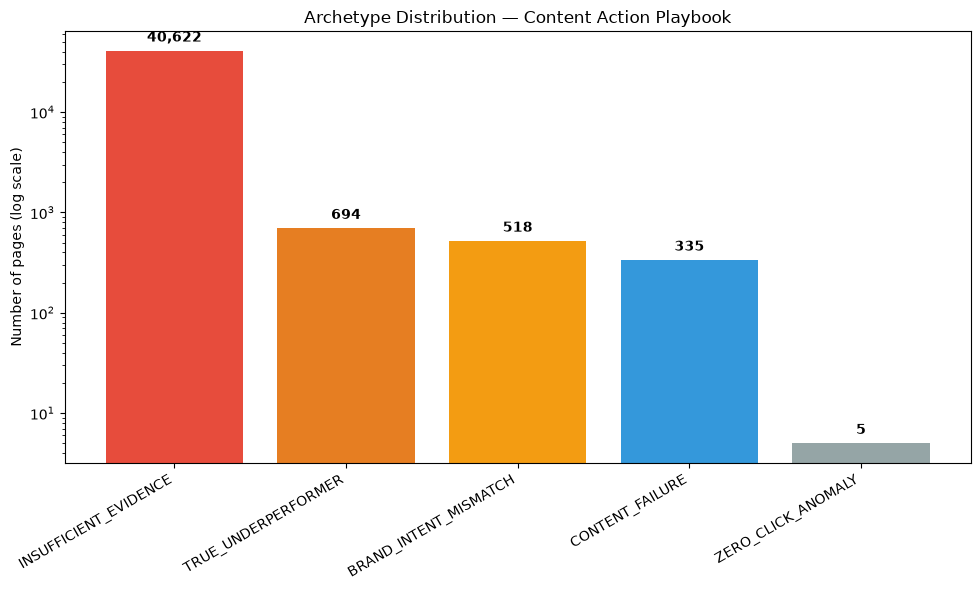

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

counts = df['archetype'].value_counts()
bars = ax.bar(range(len(counts)), counts.values, color=['#e74c3c', '#e67e22', '#f39c12', '#3498db', '#95a5a6'])

ax.set_yscale('log')
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(counts.index, rotation=30, ha='right')
ax.set_ylabel('Number of pages (log scale)')
ax.set_title('Archetype Distribution — Content Action Playbook')

# Add count labels on top of each bar
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.15,
            f'{count:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()

os.makedirs("../figures", exist_ok=True)
plt.savefig('../figures/archetype_distribution.png', dpi=150)
plt.show()


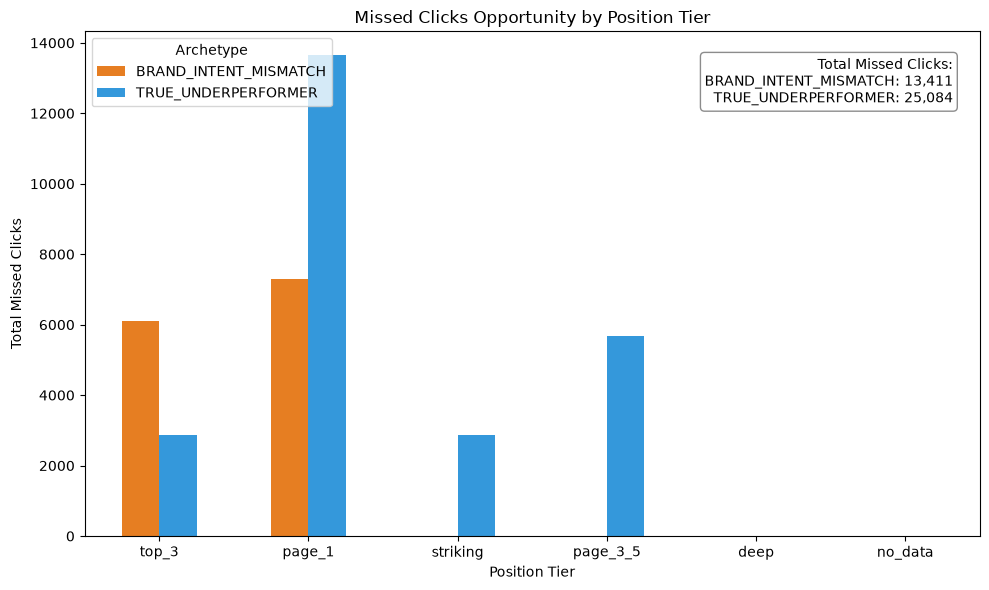

In [13]:
# --- Chart 2: Missed Clicks Opportunity by Tier (Archetypes 2 & 4) ---
fig2, ax2 = plt.subplots(figsize=(10, 6))

# Filter to just the two metadata archetypes
a2_a4_df = df[df['archetype'].isin(['BRAND_INTENT_MISMATCH', 'TRUE_UNDERPERFORMER'])]

# Group by position tier and archetype, then sum the missed clicks
clicks_pivot = a2_a4_df.groupby(['position_tier', 'archetype'], observed=False)['missed_clicks'].sum().unstack()

# Plot as a grouped bar chart
clicks_pivot.plot(kind='bar', ax=ax2, color=['#e67e22', '#3498db'])

ax2.set_ylabel('Total Missed Clicks')
ax2.set_xlabel('Position Tier')
ax2.set_title('Missed Clicks Opportunity by Position Tier')
plt.xticks(rotation=0)

# Move the legend to the upper left so it doesn't overlap our new text box
ax2.legend(title='Archetype', loc='upper left')

# Calculate the grand totals for the text box
total_brand = a2_a4_df[a2_a4_df['archetype'] == 'BRAND_INTENT_MISMATCH']['missed_clicks'].sum()
total_underperformer = a2_a4_df[a2_a4_df['archetype'] == 'TRUE_UNDERPERFORMER']['missed_clicks'].sum()

# Create a clean text box with the totals and place it in the upper right
textstr = f'Total Missed Clicks:\nBRAND_INTENT_MISMATCH: {int(total_brand):,}\nTRUE_UNDERPERFORMER: {int(total_underperformer):,}'
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
ax2.text(0.97, 0.95, textstr, transform=ax2.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right', bbox=props)

plt.tight_layout()

# Save it
plt.savefig('../figures/missed_clicks_opportunity.png', dpi=150)
plt.show()


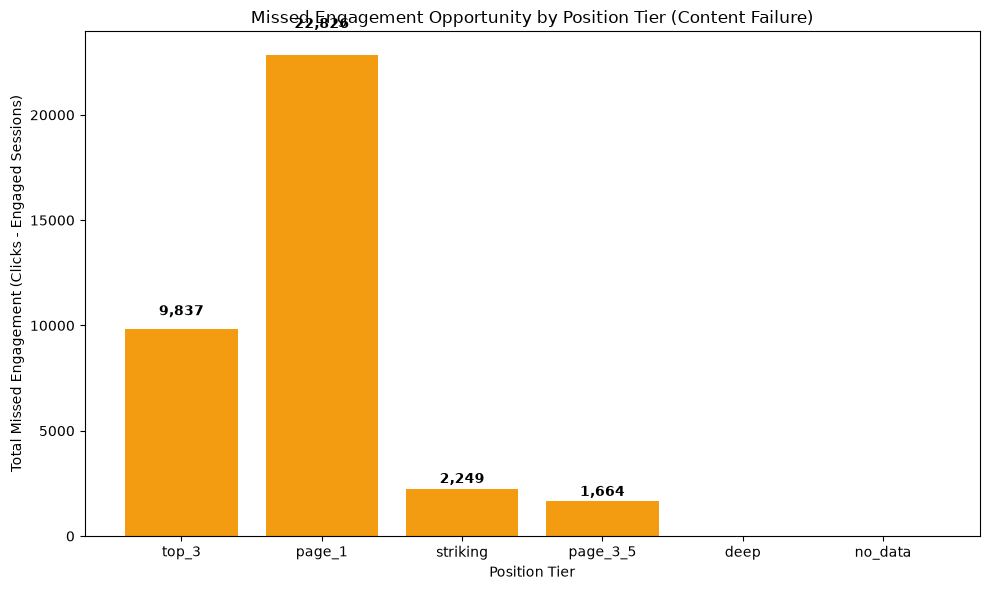

In [12]:
# --- Chart 3: Missed Engagement Opportunity by Tier (Archetype 3) ---
fig3, ax3 = plt.subplots(figsize=(10, 6))
# Filter to just the content failure archetype
a3_df = df[df['archetype'] == 'CONTENT_FAILURE']
# Group by position tier and sum missed engagement
eng_by_tier = a3_df.groupby('position_tier', observed=False)['missed_engagement'].sum()
# Plot as a single colored bar chart
bars3 = ax3.bar(eng_by_tier.index, eng_by_tier.values, color='#f39c12')
ax3.set_ylabel('Total Missed Engagement (Clicks - Engaged Sessions)')
ax3.set_xlabel('Position Tier')
ax3.set_title('Missed Engagement Opportunity by Position Tier (Content Failure)')
plt.xticks(rotation=0)
# Add clean number labels on top of the bars
for bar, val in zip(bars3, eng_by_tier.values):
    if val > 0: # Only label bars that actually have data
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.05,
                f'{int(val):,}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
# Save it
plt.savefig('../figures/missed_engagement_opportunity.png', dpi=150)
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.